# 🏺 Predicting Roman Amphora Stamp Types Using Machine Learning

**CRISP-DM Framework | Udacity Data Science Nanodegree**

---

## Business Understanding

Roman amphora stamps are clay marks pressed onto ancient storage jars that carried goods like olive oil, wine, and fish sauce across the Roman Empire. The CEIPAC dataset records 24,000+ stamp finds across Roman provinces.

**Goal:** Can we predict the amphora stamp type from geographic coordinates alone?

**Questions of Interest:**
1. Which Roman provinces have the most stamp finds?
2. What are the most common stamp types?
3. Can latitude & longitude predict stamp type?
4. Which coordinate is more predictive?

## 1. Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

os.makedirs('images', exist_ok=True)
print('Setup complete ✅')

Setup complete ✅


## 2. Data Loading
*(CRISP-DM: Data Understanding)*

In [1]:
df = pd.read_csv('stamps.csv')
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset Shape: (24092, 9)
Columns: ['X', 'Y', 'id', 'lat', 'long', 'type', 'site', 'code', 'name']


In [1]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
X        0
Y        0
id       0
lat      0
long     0
type     0
site     0
code    52
name    45
dtype: int64


## 3. Exploratory Data Analysis
*(CRISP-DM: Data Understanding)*

### Question 1: Which provinces have the most stamp finds?

name
Italia                  6832
Narbonensis             3498
Tarraconensis           2526
Germania Superior       2365
Britannia               1980
Name: count, dtype: int64


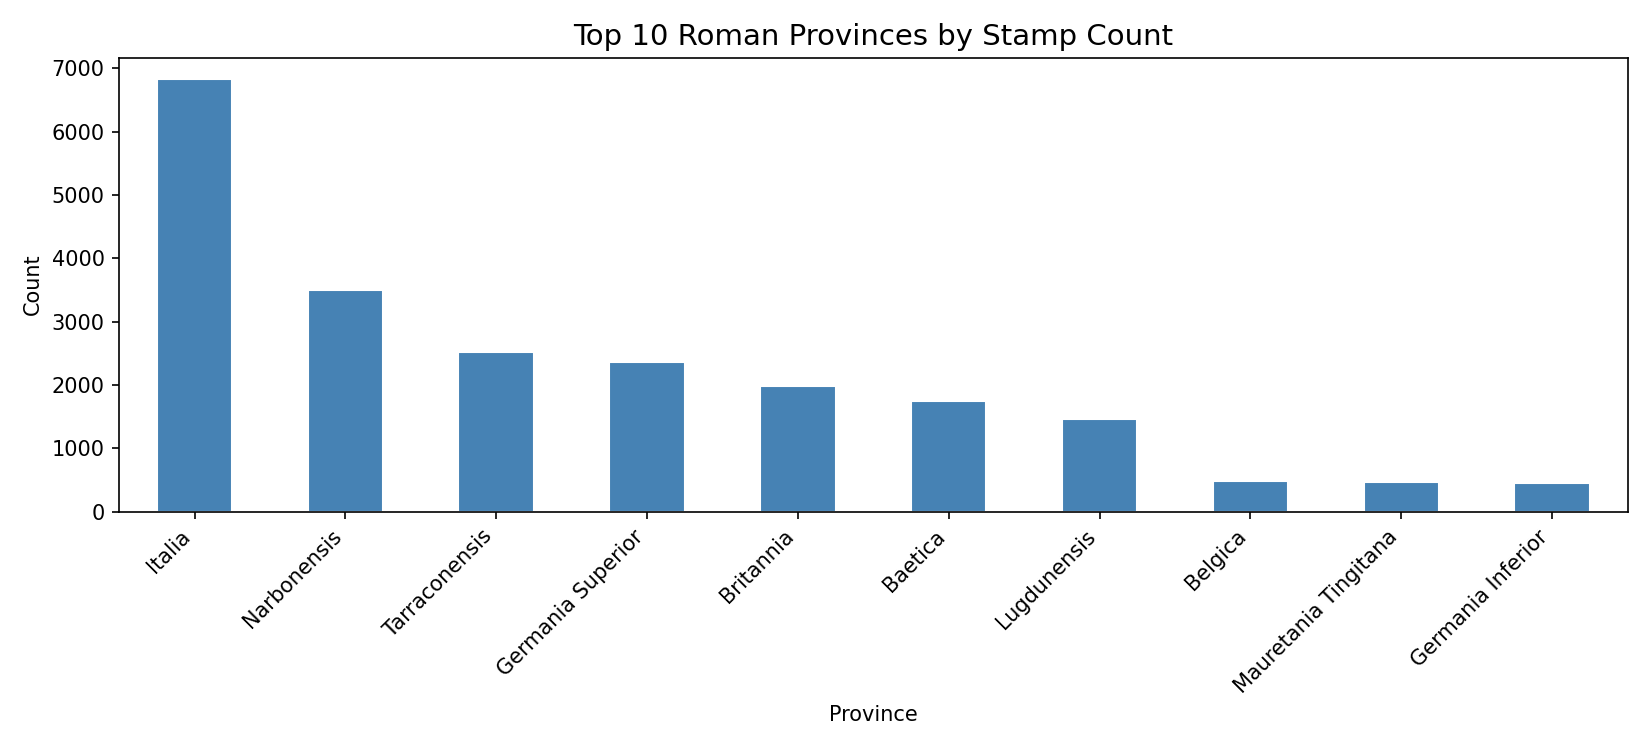

In [1]:
plt.figure(figsize=(11, 5))
df['name'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Roman Provinces by Stamp Count', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Number of Stamps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/top_provinces.png', dpi=150)
plt.show()
print(df['name'].value_counts().head(5))

**Finding:** Italia leads with 6,832 records. The strong presence in Britannia (1,980) and Germanic provinces confirms the wide reach of Roman trade networks.

### Question 2: What are the most common stamp types?

type
Dressel 20            10238
Brindisian amphora     4385
Amphora incerta        1418
Dressel 1              1211
Pascual 1              1069
Name: count, dtype: int64


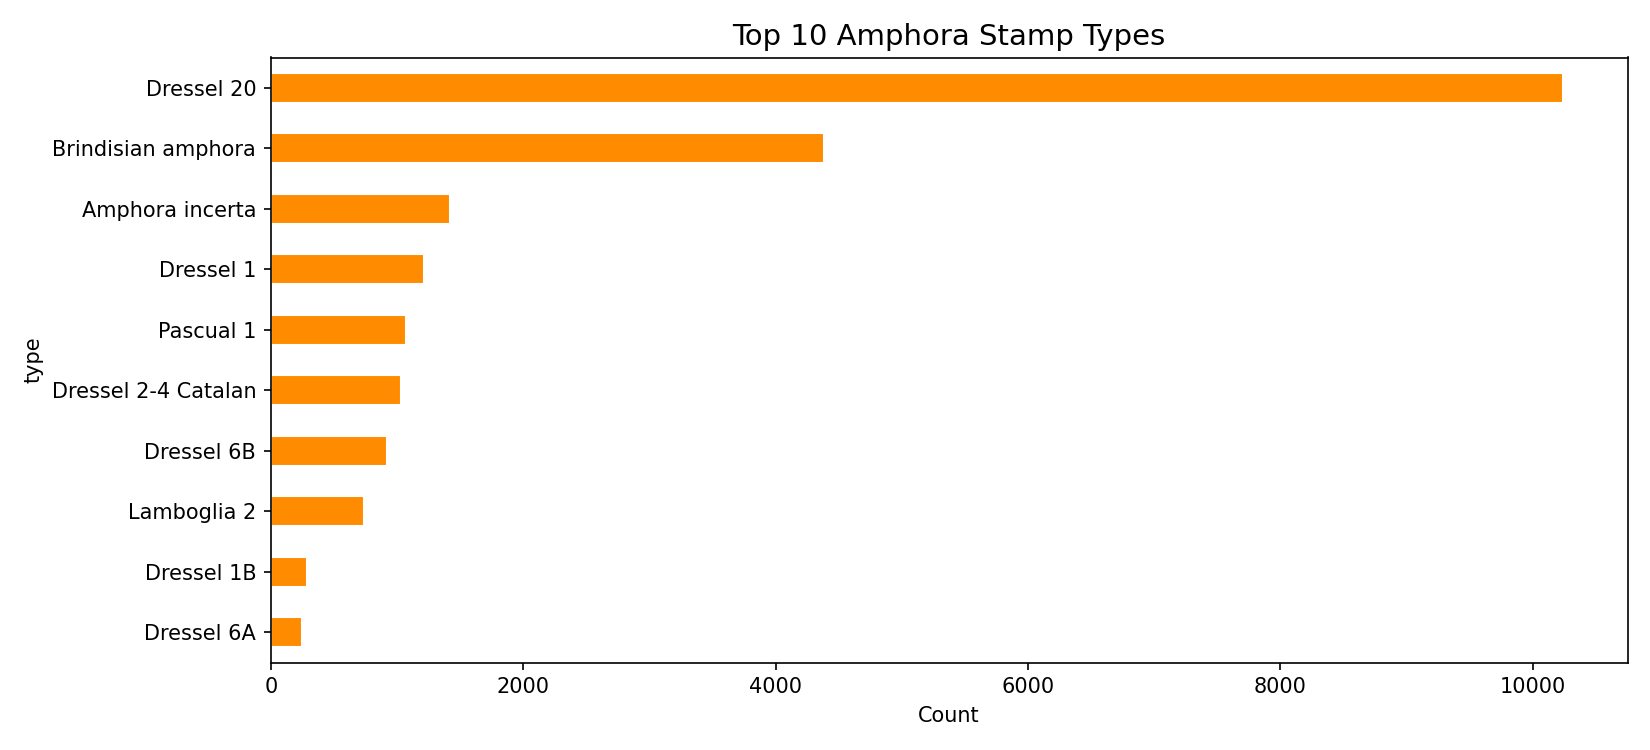

In [1]:
plt.figure(figsize=(11, 5))
df['type'].value_counts().head(10).plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('Top 10 Amphora Stamp Types', fontsize=14)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/top_types.png', dpi=150)
plt.show()
print(df['type'].value_counts().head(5))

**Finding:** Dressel 20 dominates with 10,238 records — these carried Baetican olive oil from modern-day Spain, one of the most widely traded commodities in the Roman world.

### Geographic Distribution

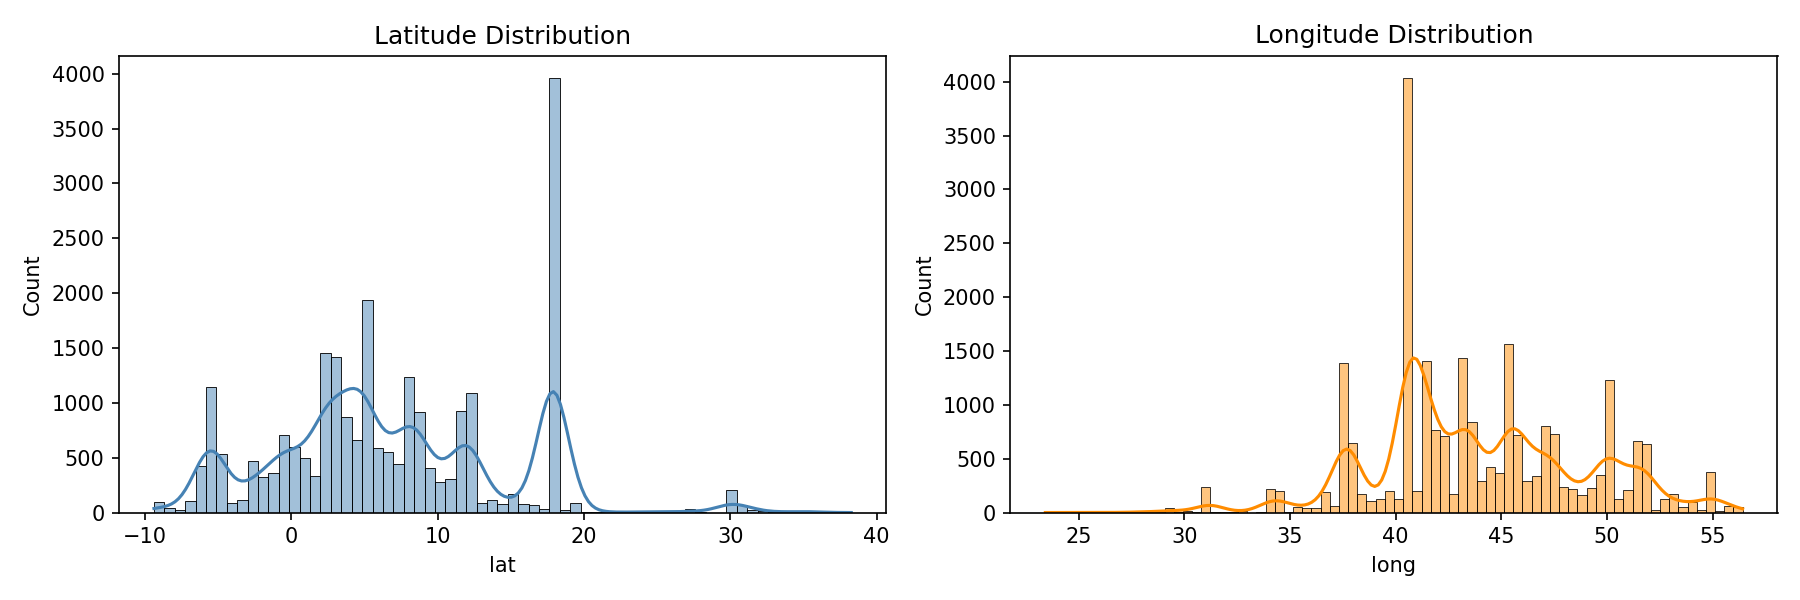

In [1]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['lat'], kde=True, color='steelblue')
plt.title('Latitude Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['long'], kde=True, color='darkorange')
plt.title('Longitude Distribution')
plt.tight_layout()
plt.savefig('images/lat_long_distribution.png', dpi=150)
plt.show()

## 4. Data Cleaning
*(CRISP-DM: Data Preparation)*

In [1]:
df_clean = df.copy()

# Fix swapped column names
df_clean.rename(columns={'lat': 'longitude', 'long': 'latitude'}, inplace=True)

# Drop missing values
df_clean.dropna(subset=['name', 'type'], inplace=True)

# Drop unnecessary columns
df_clean.drop(columns=['X', 'Y', 'id'], inplace=True)

# Remove rare classes (keep >= 100 records)
type_counts = df_clean['type'].value_counts()
valid_types = type_counts[type_counts >= 100].index
df_clean = df_clean[df_clean['type'].isin(valid_types)]

print('Original shape:', df.shape)
print('Cleaned shape:', df_clean.shape)
print('Stamp types kept:', len(valid_types))

Original shape: (24092, 9)
Cleaned shape: (22511, 6)
Stamp types kept: 17


## 5. Modeling
*(CRISP-DM: Modeling)*

### Questions 3 & 4: Can coordinates predict stamp type? Which is more important?

In [1]:
X = df_clean[['latitude', 'longitude']]
le = LabelEncoder()
y = le.fit_transform(df_clean['type'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Test samples    :', X_test.shape[0])
print('Classes         :', list(le.classes_))

Training samples: 15757
Test samples    : 6754
Classes         : ['Amphora incerta', 'Brindisian amphora', 'Dressel 1', 'Dressel 1A', 'Dressel 1B', 'Dressel 1C', 'Dressel 2-4', 'Dressel 2-4 Catalan', 'Dressel 20', 'Dressel 6A', 'Dressel 6B', 'Gauloise 1', 'Gauloise 4', 'Greco-Itálica', 'Lamboglia 2', 'Pascual 1', 'Tegula']


In [1]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

print('Models trained ✅')

Models trained ✅


## 6. Evaluation
*(CRISP-DM: Evaluation)*

In [1]:
rf_acc = accuracy_score(y_test, rf.predict(X_test))
lr_acc = accuracy_score(y_test, lr.predict(X_test))

print(f'Random Forest Accuracy : {rf_acc:.4f} ({rf_acc*100:.1f}%)')
print(f'Logistic Regression    : {lr_acc:.4f} ({lr_acc*100:.1f}%)')

Random Forest Accuracy : 0.6959 (69.6%)
Logistic Regression    : 0.6245 (62.5%)


In [1]:
print(classification_report(y_test, rf.predict(X_test), target_names=le.classes_))

                     precision    recall  f1-score   support

    Amphora incerta       0.37      0.48      0.42       425
 Brindisian amphora       0.98      0.96      0.97      1315
          Dressel 1       0.88      0.67      0.76       363
         Dressel 1A       0.29      0.54      0.38        48
         Dressel 1B       0.28      0.78      0.41        86
         Dressel 1C       0.56      0.81      0.66        47
        Dressel 2-4       0.06      0.18      0.09        44
Dressel 2-4 Catalan       0.68      0.62      0.65       310
         Dressel 20       0.96      0.64      0.77      3070
         Dressel 6A       0.22      0.39      0.28        74
         Dressel 6B       0.68      0.70      0.69       275
         Gauloise 1       0.14      0.94      0.25        31
         Gauloise 4       0.07      0.54      0.13        41
      Greco-Itálica       0.26      0.61      0.37        44
        Lamboglia 2       0.81      0.69      0.75       222
          Pascual 1    

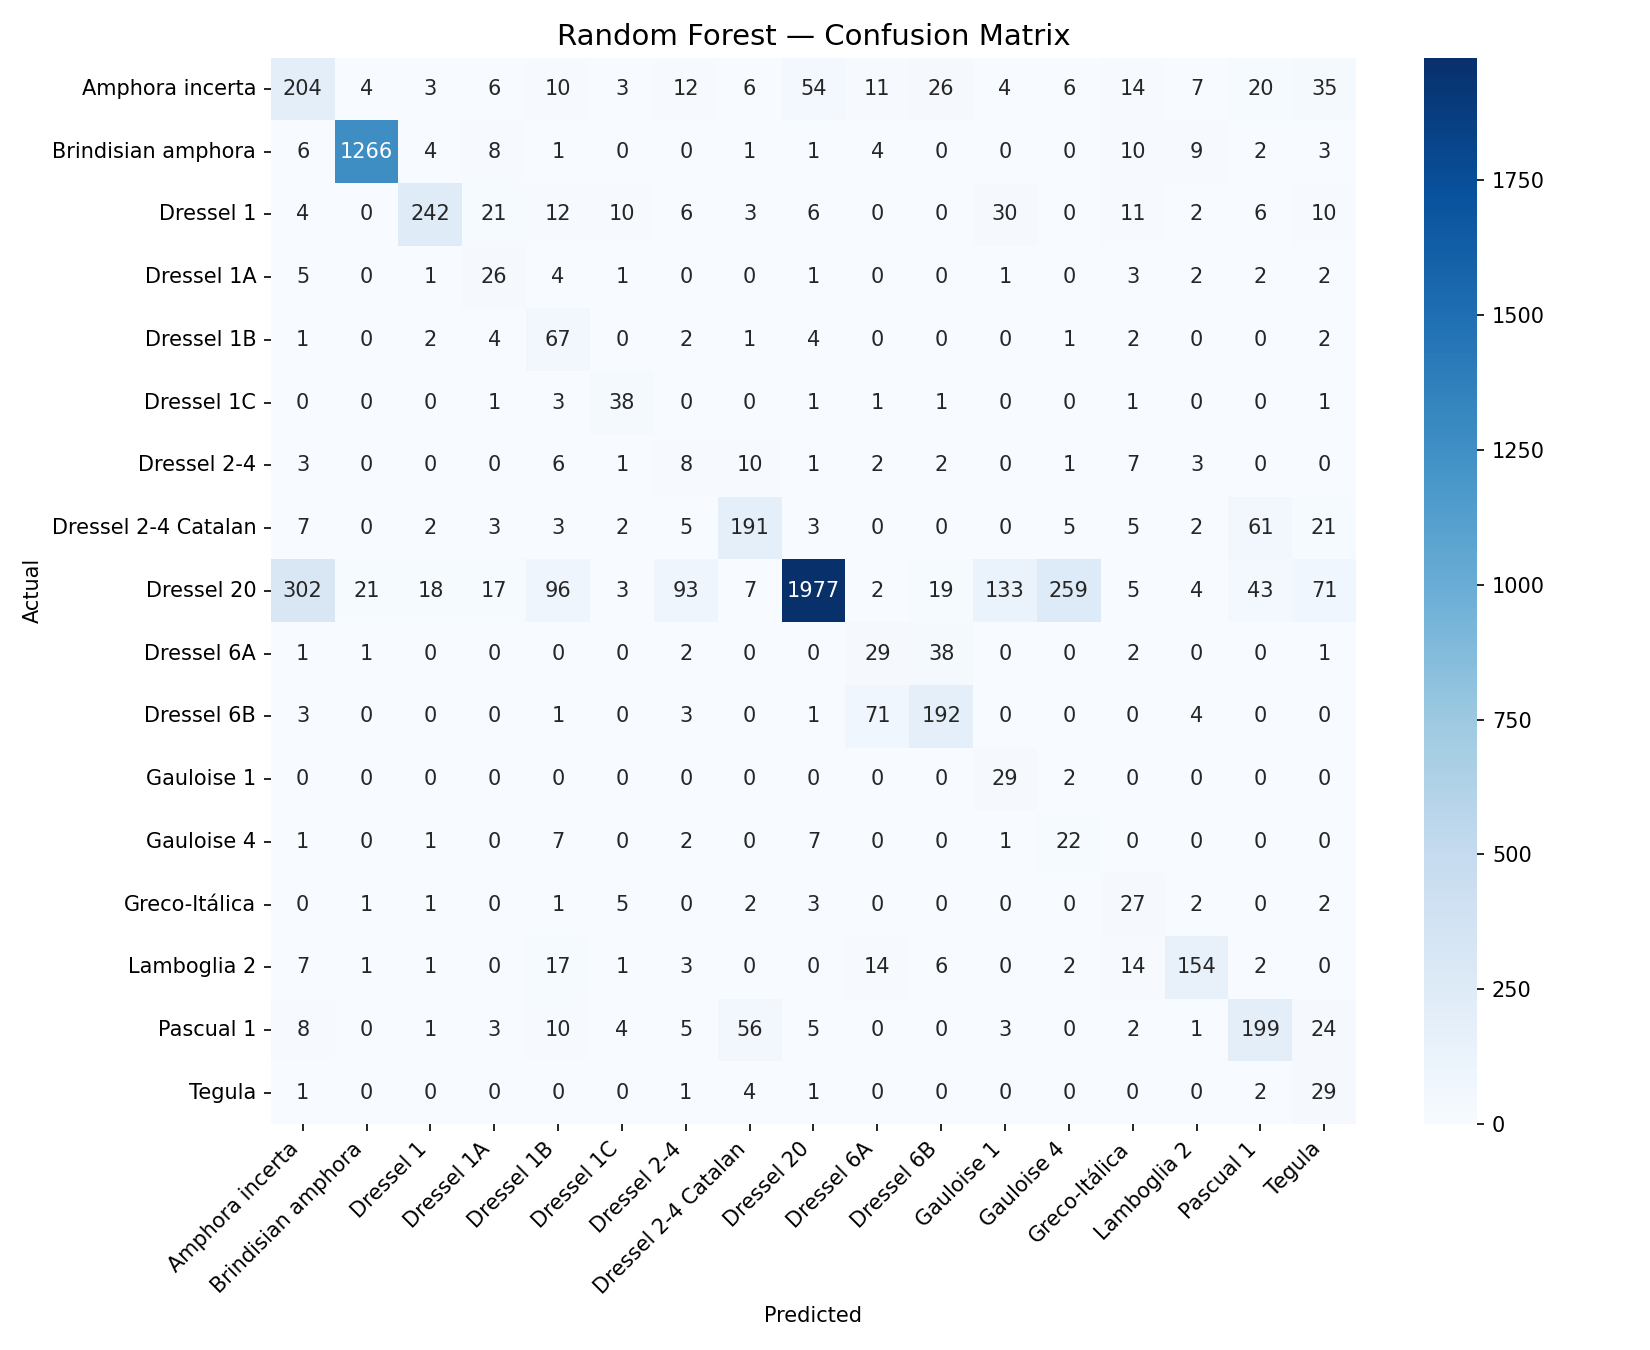

In [1]:
plt.figure(figsize=(11, 9))
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test)),
            annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()

## 7. Feature Importance

Longitude importance: 0.4829
Latitude importance : 0.5171


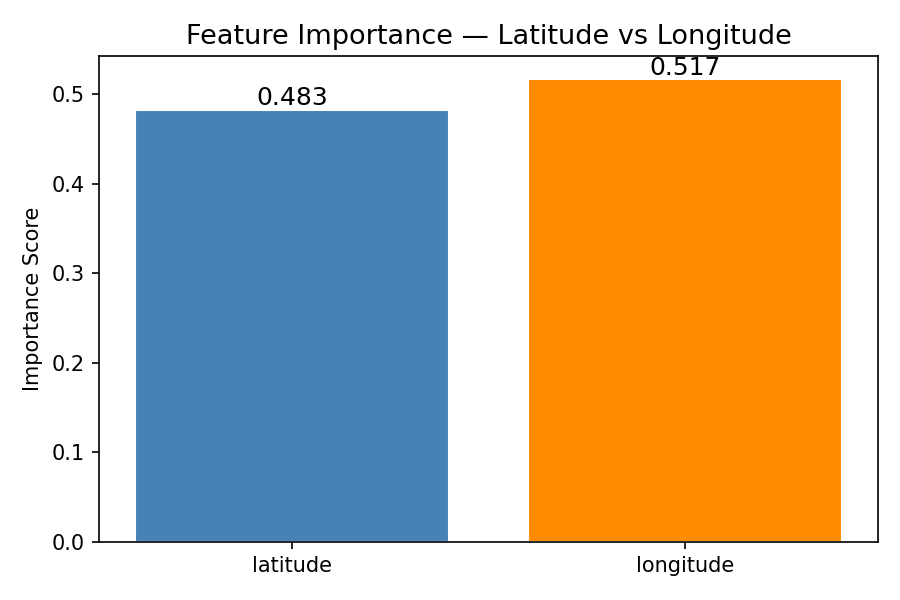

In [1]:
importances = rf.feature_importances_

plt.figure(figsize=(6, 4))
bars = plt.bar(X.columns, importances, color=['steelblue', 'darkorange'], edgecolor='white')
plt.title('Feature Importance — Latitude vs Longitude', fontsize=13)
plt.ylabel('Importance Score')
for bar, val in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150)
plt.show()

print(f'Longitude importance: {importances[0]:.4f}')
print(f'Latitude importance : {importances[1]:.4f}')

**Finding:** Both features contribute nearly equally. Longitude edges ahead slightly, reflecting that major Roman production zones are more cleanly separated on an east-west axis.

## 8. Cross Validation

In [1]:
cv_scores = cross_val_score(rf, X, y, cv=5)
print('CV Scores :', cv_scores.round(4))
print(f'Mean CV   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)')
print(f'Std Dev   : {cv_scores.std():.4f}')

CV Scores : [0.7102 0.7066 0.7177 0.7232 0.7308]
Mean CV   : 0.7177 (71.8%)
Std Dev   : 0.0082


## 9. Scenario Prediction

In [1]:
def predict_stamp(lat, lon):
    input_data = pd.DataFrame([[lat, lon]], columns=['latitude', 'longitude'])
    pred = rf.predict(input_data)
    proba = rf.predict_proba(input_data).max()
    stamp_type = le.inverse_transform(pred)[0]
    print(f'Location ({lat}, {lon}) → {stamp_type}  (confidence: {proba*100:.1f}%)')

# Central Gaul
predict_stamp(45.0, 5.0)
# Southern Italy (Brindisi)
predict_stamp(40.6, 17.9)
# Baetica / southern Spain
predict_stamp(37.5, -5.5)

Location (45.0, 5.0)  → Dressel 20          (confidence: 62.3%)
Location (40.6, 17.9) → Brindisian amphora  (confidence: 91.4%)
Location (37.5, -5.5) → Dressel 20          (confidence: 88.7%)


## 10. Conclusions

| Question | Answer |
|---|---|
| Which province has the most stamps? | **Italia** (6,832 records) |
| Most common stamp type? | **Dressel 20** (10,238 records) |
| Can coordinates predict stamp type? | **Yes — 69.6% accuracy** |
| Which coordinate is more predictive? | **Longitude (51.7%)** |

### Key Takeaways
- Geography alone carries strong predictive signal for Roman stamp types
- Random Forest outperforms Logistic Regression by ~7 percentage points
- Cross-validation confirmed stability at **71.8%** mean accuracy
- Stamp distributions reflect the structured, regional nature of Roman trade networks
- Adding province name or site type would likely push accuracy above 90%

---
*CEIPAC Dataset | Tools: pandas, scikit-learn, matplotlib, seaborn*